<h3><b>Implement Deep Feed Forward Neural Network (DFFNN) with Mini-Batch/Stochastic Gradient Descent Algorithm</b></h3>

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets
import scipy.io
import time
import h5py

In [47]:
def layer_sizes(X, Y, num_hidden_units):

    num_input_units = [X.shape[0]]
    num_hidden_units = list(num_hidden_units)
    num_output_units = [Y.shape[0]]
    layer_units = list(num_input_units + num_hidden_units + num_output_units)

    return layer_units

In [48]:
def initialize_parameters(layer_units):

    parameters = {}
    L = len(layer_units)

    for l in range(1, L):
        parameters[f"W{l}"] = np.random.randn(layer_units[l], layer_units[l-1]) * np.sqrt(2 / layer_units[l - 1])
        parameters[f"b{l}"] = np.zeros((layer_units[l], 1))

    return parameters

In [49]:
def relu(Z):
    A = np.maximum(0, Z)
    cache = Z

    return A, cache

In [50]:
def sigmoid(Z):

    A = 1 / (1 + np.exp(-Z))
    cache = Z

    return A, cache

In [51]:
def forward_propagation(X, parameters):

    caches = []
    A = X
    L = len(parameters) // 2

    for l in range(1, L):
        A_prev = A
        W = parameters[f"W{l}"]
        b = parameters[f"b{l}"]

        linear_cache = (A_prev, W, b)
        Z = np.dot(W, A_prev) + b
        A, activation_cache = relu(Z)
        caches.append((linear_cache, activation_cache))

    A_prev = A
    W = parameters[f"W{L}"]
    b = parameters[f"b{L}"]
    linear_cache = (A_prev, W, b)

    Z = np.dot(W, A_prev) + b
    A, activation_cache = sigmoid(Z)

    caches.append((linear_cache, activation_cache))

    return A, caches

In [52]:
def compute_cost(A, Y):
    
    """
    This is used with mini-batches, 
    so we'll first accumulate costs over an entire epoch 
    and then divide by the m training examples
    """
    
    logprobs = np.multiply(-np.log(A + 1e-15), Y) + np.multiply(-np.log(1 - A + 1e-15), 1 - Y)
    cost_total =  np.sum(logprobs)
    
    return cost_total

In [53]:
def backward_sigmoid(dA, Z):

    A = 1 / (1 + np.exp(-Z))
    dZ = np.multiply(np.multiply(dA, A), 1 - A)

    return dZ

In [54]:
def backward_relu(dA, cache):

    dZ = np.array(dA, copy=True)
    dZ[cache <= 0] = 0

    return dZ

In [55]:
def backward_propagation(AL, Y, caches):
    
    Y = Y.reshape(AL.shape)
    L = len(caches)
    gradients = {}

    dAL = - (np.divide(Y, AL + 1e-15) - np.divide(1 - Y, 1 - AL + 1e-15))

    (linear_cache, activation_cache) = caches[-1]
    (A_prev, W, b) = linear_cache
    m = A_prev.shape[1]

    dZ = backward_sigmoid(dAL, activation_cache)
    gradients[f"dA{L-1}"] = np.dot(W.T, dZ)
    gradients[f"dW{L}"] = 1 / m * np.dot(dZ, A_prev.T)
    gradients[f"db{L}"] = 1 / m * np.sum(dZ, axis=1, keepdims=True)

    for l in reversed(range(L - 1)):

        (linear_cache, activation_cache) = caches[l]
        (A_prev, W, b) = linear_cache
        m = A_prev.shape[1]

        dZ = backward_relu(gradients[f"dA{l+1}"], activation_cache)
        gradients[f"dA{l}"] = np.dot(W.T, dZ)
        gradients[f"dW{l+1}"] = 1 / m * np.dot(dZ, A_prev.T)
        gradients[f"db{l+1}"] = 1 / m * np.sum(dZ, axis=1, keepdims=True)

    return gradients

In [56]:
def update_parameters(parameters, gradients, learning_rate):

    L = len(parameters) // 2

    for l in range(1, L + 1):

        parameters[f"W{l}"] -= learning_rate * gradients[f"dW{l}"]
        parameters[f"b{l}"] -= learning_rate * gradients[f"db{l}"]

    return parameters

In [57]:
def predict(X, parameters):

    A, _ = forward_propagation(X, parameters)

    A = (A > 0.5).astype(int)

    return A

In [58]:
def accuracy(A, Y):
    
    accuracy = np.sum((A == Y) / Y.shape[1])

    return accuracy

In [59]:
def random_mini_batches(X, Y, mini_batch_size, seed):

    np.random.seed(seed) 
    m = X.shape[1]  
    mini_batches = []
        
    
    permutation = np.random.permutation(m)
    shuffled_X = X[:, permutation]
    shuffled_Y = Y[:, permutation].reshape((1, m))
    
    # Step 2: Partition the shuffled data into mini-batches
    num_complete_minibatches = m // mini_batch_size  
    
    for k in range(num_complete_minibatches):
        start_idx = k * mini_batch_size
        end_idx = (k + 1) * mini_batch_size
        mini_batch_X = shuffled_X[:, start_idx:end_idx]
        mini_batch_Y = shuffled_Y[:, start_idx:end_idx]
        mini_batches.append((mini_batch_X, mini_batch_Y))
    
    # Handling the end case (last mini-batch may have fewer examples)
    if m % mini_batch_size != 0:
        start_idx = num_complete_minibatches * mini_batch_size
        mini_batch_X = shuffled_X[:, start_idx:]
        mini_batch_Y = shuffled_Y[:, start_idx:]
        mini_batches.append((mini_batch_X, mini_batch_Y))
    
    return mini_batches

In [60]:
def train(X_train, Y_train, X_test, Y_test, num_hidden_units, num_epochs=1000, learning_rate=1e-3, mini_batch_size=64, epsilon=100, seed=1):
    
    train_time = 0
    cost_ = []
    num_layer_units = layer_sizes(X_train, Y_train, num_hidden_units)
    parameters = initialize_parameters(num_layer_units)

    m = X_train.shape[1]
    
    for i in range(num_epochs):
        
        tic = time.time()
        seed = seed + 1
        minibatches = random_mini_batches(X_train, Y_train, mini_batch_size, seed)
        cost_total = 0
        
        for minibatch in minibatches:

            (X_minibatch, Y_minibatch) = minibatch 
            A_minibatch, minibatch_caches = forward_propagation(X_minibatch, parameters)
            cost_total += compute_cost(A_minibatch, Y_minibatch)
            gradients = backward_propagation(A_minibatch, Y_minibatch, minibatch_caches)
            
            parameters = update_parameters(parameters, gradients, learning_rate)
        
        toc = time.time()
        train_time += toc - tic
        cost_.append(cost_total / m)
        
        if i % epsilon == 0:
            print(f"Epoch: {i}; Cost: {cost_total / m}")

    train_accuracy = accuracy(predict(X_train, parameters), Y_train)
    test_accuracy = accuracy(predict(X_test, parameters), Y_test)
    
    print(f"Train Accuracy: {train_accuracy}")
    print(f"Test Accuracy: {test_accuracy}")
    print(f"Train Duration: {train_time}")

    plt.plot(cost_)
    plt.title("epoch vs. cost")
    plt.xlabel("# epoch")
    plt.ylabel("cost")
    
    return parameters        

In [27]:
def load_dataset():
    np.random.seed(3)
    train_X, train_Y = sklearn.datasets.make_moons(n_samples=1000, noise=.3) #300 #0.2 
    # Visualize the data
    plt.scatter(train_X[:, 0], train_X[:, 1], c=train_Y, s=40, cmap=plt.cm.Spectral);
    train_X = train_X.T
    train_Y = train_Y.reshape((1, train_Y.shape[0]))
    
    return train_X, train_Y

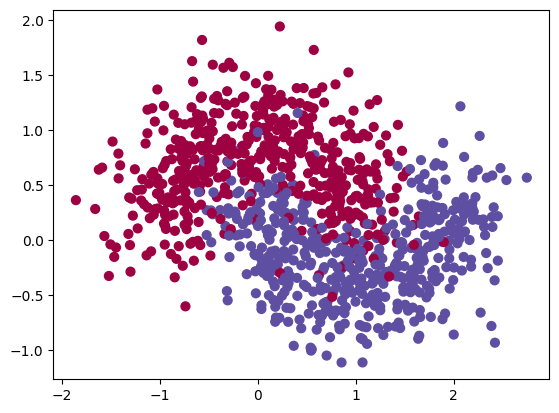

In [28]:
X_train_, Y_train_ = load_dataset()

In [29]:
X_train = X_train_[:, :900]
Y_train = Y_train_[: , :900]
X_test = X_train_[:, 900:]
Y_test = Y_train_[: , 900:]

print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(2, 900)
(1, 900)
(2, 100)
(1, 100)


Epoch: 0; Cost: 1.2945438321853893
Epoch: 500; Cost: 0.6132188859654458
Epoch: 1000; Cost: 0.4937203641654552
Epoch: 1500; Cost: 0.4284902890629404
Epoch: 2000; Cost: 0.3919409697566015
Epoch: 2500; Cost: 0.36873206273103387
Epoch: 3000; Cost: 0.3520756372784655
Epoch: 3500; Cost: 0.33893739564301356
Epoch: 4000; Cost: 0.327283724691732
Epoch: 4500; Cost: 0.3167179534310746
Epoch: 5000; Cost: 0.30709868721769606
Epoch: 5500; Cost: 0.29854156956529104
Epoch: 6000; Cost: 0.29001335280036944
Epoch: 6500; Cost: 0.28137484864227064
Epoch: 7000; Cost: 0.27279274484292865
Epoch: 7500; Cost: 0.2641695635822603
Epoch: 8000; Cost: 0.25545875611047714
Epoch: 8500; Cost: 0.2466033676426436
Epoch: 9000; Cost: 0.23817989790746527
Epoch: 9500; Cost: 0.2305129148022477
Epoch: 10000; Cost: 0.22367354115437932
Epoch: 10500; Cost: 0.2180397803221934
Epoch: 11000; Cost: 0.21293876632336592
Epoch: 11500; Cost: 0.20850934468021276
Epoch: 12000; Cost: 0.2048736827143377
Epoch: 12500; Cost: 0.2021230210183818

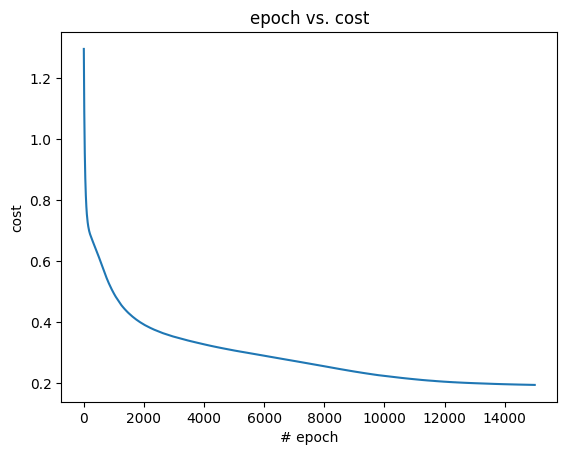

In [34]:
params = train(X_train, Y_train, X_test, Y_test, [10, 10, 6, 3], num_epochs=15000, learning_rate=3e-4, mini_batch_size=64, epsilon=500, seed=1)

In [61]:
train_dataset = h5py.File("/home/samani/Documents/projects/deep-learning/data/train_cat.h5", "r")
train_set_x_orig = np.array(train_dataset["train_set_x"][:])
train_set_y_orig = np.array(train_dataset["train_set_y"][:])  

test_dataset = h5py.File("/home/samani/Documents/projects/deep-learning/data/test_cat.h5", "r")
test_set_x_orig = np.array(test_dataset["test_set_x"][:])  
test_set_y_orig = np.array(test_dataset["test_set_y"][:])  

classes = np.array(test_dataset["list_classes"][:])

train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))

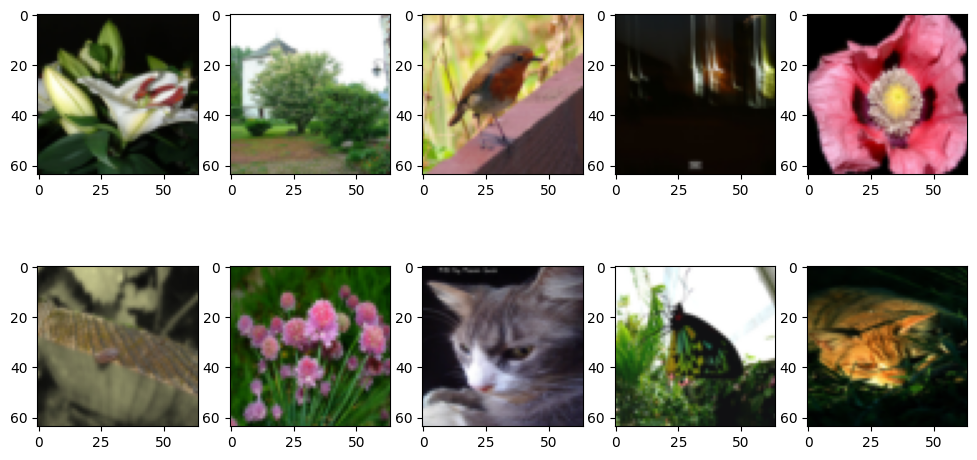

In [62]:
plt.figure(figsize=(12, 6))
plt.subplot(2, 5, 1)
plt.imshow(train_set_x_orig[4])
plt.subplot(2, 5, 2)
plt.imshow(train_set_x_orig[55])
plt.subplot(2, 5, 3)
plt.imshow(train_set_x_orig[10])
plt.subplot(2, 5, 4)
plt.imshow(train_set_x_orig[207])
plt.subplot(2, 5, 5)
plt.imshow(train_set_x_orig[140])
plt.subplot(2, 5, 6)
plt.imshow(train_set_x_orig[12])
plt.subplot(2, 5, 7)
plt.imshow(train_set_x_orig[21])
plt.subplot(2, 5, 8)
plt.imshow(train_set_x_orig[71])
plt.subplot(2, 5, 9)
plt.imshow(train_set_x_orig[16])
plt.subplot(2, 5, 10)
plt.imshow(train_set_x_orig[41])

plt.show()

In [41]:
train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T
print(train_set_x_flatten.shape)
print(test_set_x_flatten.shape)

(12288, 209)
(12288, 50)


In [43]:
X_train = train_set_x_flatten / 255
Y_train = train_set_y_orig
X_test = test_set_x_flatten / 255
Y_test = test_set_y_orig
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(12288, 209)
(1, 209)
(12288, 50)
(1, 50)


Epoch: 0; Cost: 0.702060475216363
Epoch: 500; Cost: 0.6680157553384433
Epoch: 1000; Cost: 0.649767136293393
Epoch: 1500; Cost: 0.6325020148553004
Epoch: 2000; Cost: 0.6069138897449039
Epoch: 2500; Cost: 0.5591417811020511
Epoch: 3000; Cost: 0.484787260692026
Epoch: 3500; Cost: 0.3821954157566455
Epoch: 4000; Cost: 0.2891196584916643
Epoch: 4500; Cost: 0.22447448356490618
Epoch: 5000; Cost: 0.18003097974512985
Epoch: 5500; Cost: 0.15012882480022127
Epoch: 6000; Cost: 0.12666734327675255
Epoch: 6500; Cost: 0.09449733620729708
Epoch: 7000; Cost: 0.07899702844436349
Epoch: 7500; Cost: 0.06910105909899161
Epoch: 8000; Cost: 0.06205749291931771
Epoch: 8500; Cost: 0.0565632760598305
Epoch: 9000; Cost: 0.05288564926573871
Epoch: 9500; Cost: 0.0492061277735955
Train Accuracy: 0.9952153110047846
Test Accuracy: 0.6400000000000001
Train Duration: 256.7000503540039


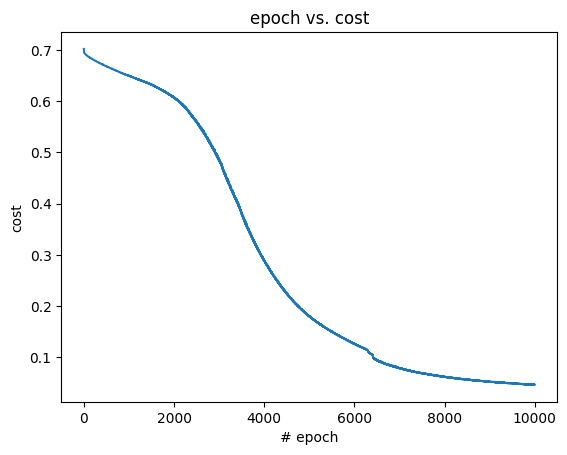

In [44]:
params = train(X_train, Y_train, X_test, Y_test, [10, 10, 6, 3], num_epochs=10000, learning_rate=3e-4, mini_batch_size=32, epsilon=500, seed=1)

Epoch: 0; Cost: 0.6979983301237171
Epoch: 500; Cost: 0.42211091267890255
Epoch: 1000; Cost: 0.3261118907996049
Epoch: 1500; Cost: 0.2762951591144578
Epoch: 2000; Cost: 0.24344479435557098
Epoch: 2500; Cost: 0.21896095586888298
Epoch: 3000; Cost: 0.20355582954391654
Epoch: 3500; Cost: 0.1892994339871119
Train Accuracy: 0.9856459330143538
Test Accuracy: 0.6000000000000001
Train Duration: 93.71123313903809


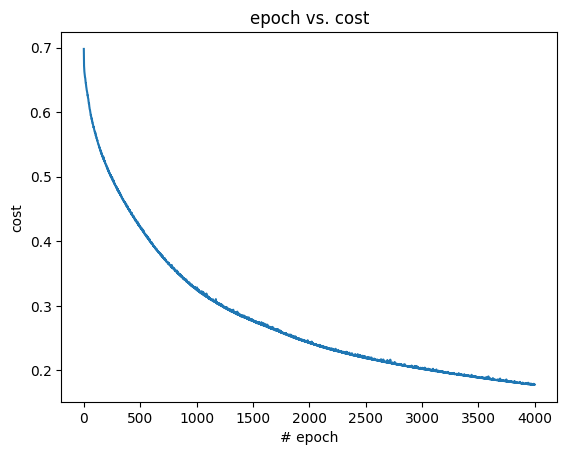

In [63]:
params = train(X_train, Y_train, X_test, Y_test, [10, 10, 6, 3], num_epochs=4000, learning_rate=2e-4, mini_batch_size=32, epsilon=500, seed=1)

Epoch: 0; Cost: 1.0074966091853252
Epoch: 500; Cost: 0.3227754528678424
Epoch: 1000; Cost: 0.1382768963770999
Epoch: 1500; Cost: 0.09449922803010385
Epoch: 2000; Cost: 0.06625006179562468
Epoch: 2500; Cost: 0.045615276271597505
Epoch: 3000; Cost: 0.029973191234355014
Epoch: 3500; Cost: 0.022191925432608218
Train Accuracy: 0.9999999999999998
Test Accuracy: 0.78
Train Duration: 105.78311729431152


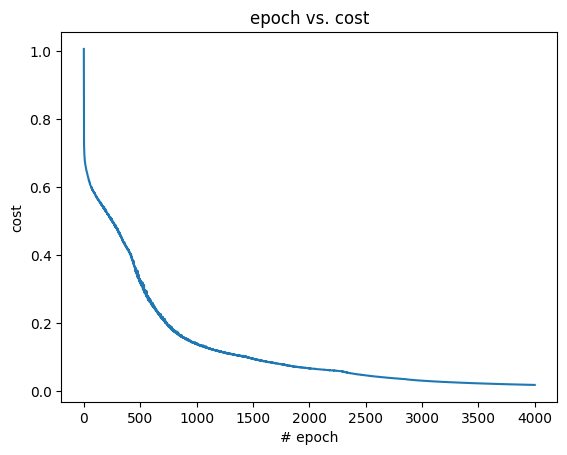

In [64]:
params = train(X_train, Y_train, X_test, Y_test, [10, 6], num_epochs=4000, learning_rate=2e-4, mini_batch_size=32, epsilon=500, seed=1)

Epoch: 0; Cost: 1.0993080559569564
Epoch: 500; Cost: 0.5013005990564641
Epoch: 1000; Cost: 0.3326757660926631
Epoch: 1500; Cost: 0.20130713971503308
Epoch: 2000; Cost: 0.14058231754565756
Epoch: 2500; Cost: 0.11407405374732324
Train Accuracy: 0.9856459330143539
Test Accuracy: 0.7
Train Duration: 79.53706645965576


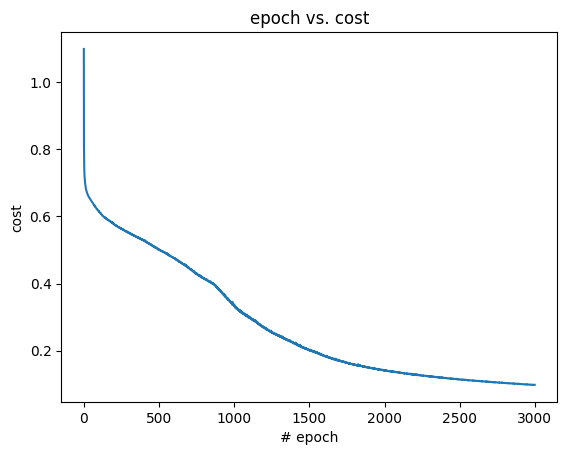

In [65]:
params = train(X_train, Y_train, X_test, Y_test, [10, 6], num_epochs=3000, learning_rate=1e-4, mini_batch_size=32, epsilon=500, seed=1)

Epoch: 0; Cost: 0.9560262056606159
Epoch: 500; Cost: 0.6098413464394126
Epoch: 1000; Cost: 0.5713951276648407
Epoch: 1500; Cost: 0.5291192081146543
Epoch: 2000; Cost: 0.36534788479996394
Epoch: 2500; Cost: 0.22859963695561533
Train Accuracy: 0.9904306220095691
Test Accuracy: 0.74
Train Duration: 64.90174293518066


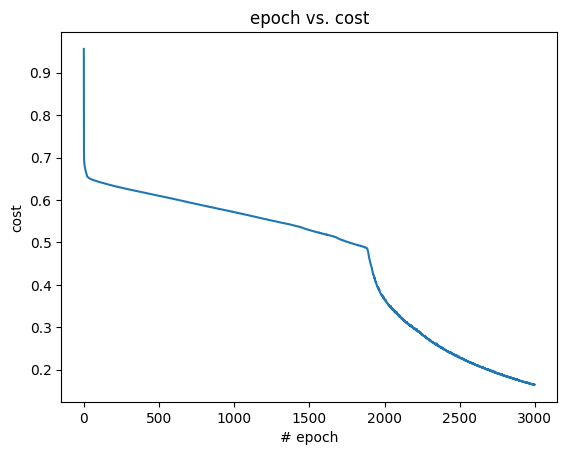

In [66]:
params = train(X_train, Y_train, X_test, Y_test, [8, 4], num_epochs=3000, learning_rate=1e-4, mini_batch_size=32, epsilon=500, seed=1)

In [74]:
def load_2D_dataset():
    data = scipy.io.loadmat("/home/samani/Documents/projects/deep-learning/data/data.mat")
    train_X = data['X'].T
    train_Y = data['y'].T
    test_X = data['Xval'].T
    test_Y = data['yval'].T

    plt.scatter(train_X[0, :], train_X[1, :], c=train_Y, s=40, cmap=plt.cm.Spectral);
    
    return train_X, train_Y, test_X, test_Y

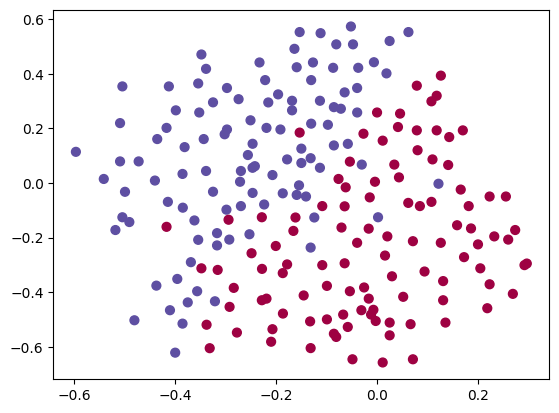

In [75]:
train_X, train_Y, test_X, test_Y = load_2D_dataset()

Epoch: 0; Cost: 0.6582577245787186
Epoch: 100; Cost: 0.16937802682157063
Epoch: 200; Cost: 0.0523943901069215
Epoch: 300; Cost: 0.025072969664986983
Epoch: 400; Cost: 0.014884643011446397
Epoch: 500; Cost: 0.010180360798532757
Epoch: 600; Cost: 0.0074752469375072355
Epoch: 700; Cost: 0.005863344129126075
Epoch: 800; Cost: 0.004793805153944399
Epoch: 900; Cost: 0.003984917791854408
Train Accuracy: 0.9999999999999998
Test Accuracy: 0.7
Train Duration: 197.21856427192688


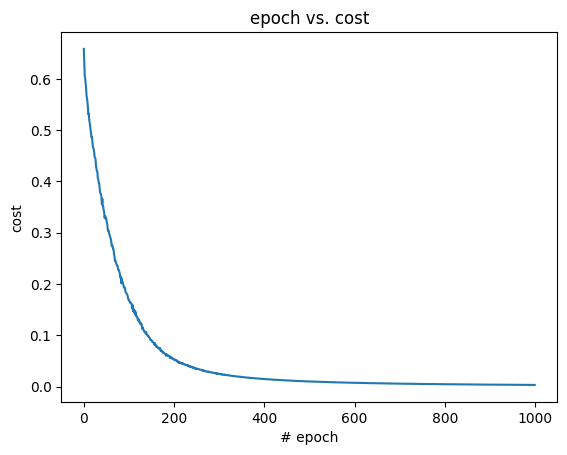

In [76]:
params = train(X_train, Y_train, X_test, Y_test, [8, 4], num_epochs=1000, learning_rate=1e-4, mini_batch_size=1, epsilon=100, seed=1)

Epoch: 0; Cost: 0.7705135669052859
Epoch: 50; Cost: 0.5880578752491445
Epoch: 100; Cost: 0.5393292981702058
Epoch: 150; Cost: 0.4899293707210912
Epoch: 200; Cost: 0.4440199385830433
Epoch: 250; Cost: 0.404310268725188
Epoch: 300; Cost: 0.3736921884532086
Epoch: 350; Cost: 0.34635712993961115
Train Accuracy: 0.9234449760765548
Test Accuracy: 0.68
Train Duration: 82.48374915122986


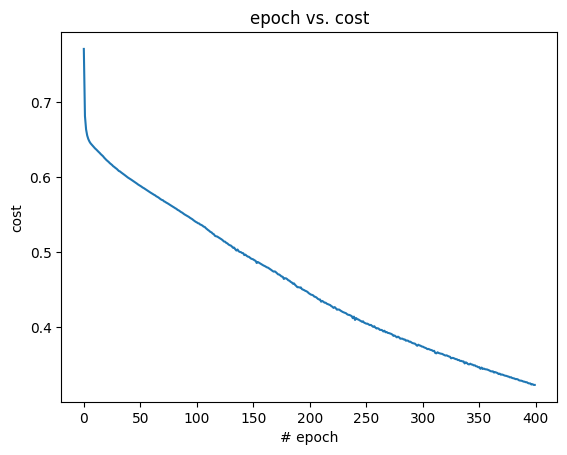

In [77]:
params = train(X_train, Y_train, X_test, Y_test, [8, 4], num_epochs=400, learning_rate=1e-5, mini_batch_size=1, epsilon=50, seed=1)

Epoch: 0; Cost: 0.6936243210632578
Epoch: 50; Cost: 0.49971674842282204
Epoch: 100; Cost: 0.3648850650795796
Epoch: 150; Cost: 0.2699098019034715
Epoch: 200; Cost: 0.20516069746226193
Epoch: 250; Cost: 0.16214625006531888
Epoch: 300; Cost: 0.13142642827515344
Epoch: 350; Cost: 0.10628345514780291
Train Accuracy: 0.9856459330143539
Test Accuracy: 0.7000000000000001
Train Duration: 77.00155854225159


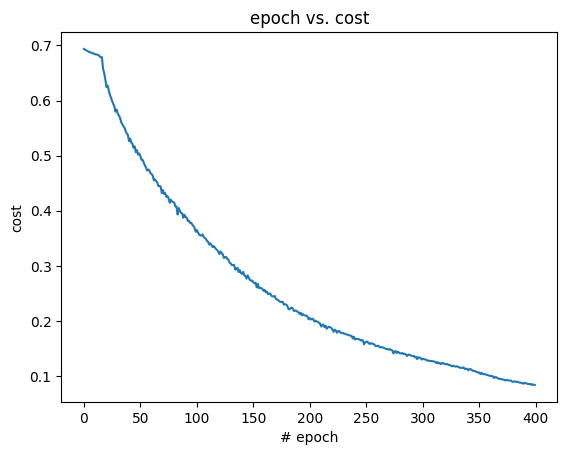

In [78]:
params = train(X_train, Y_train, X_test, Y_test, [8, 4], num_epochs=400, learning_rate=4e-5, mini_batch_size=1, epsilon=50, seed=1)